<h1>레퍼런스 사이트</h1>

**레퍼런스 사이트 외의 웹사이트나 프로그램 등을 실행할 경우 부정행위로 간주되어 퇴실 조치될 수 있습니다.**<br>
아래 사이트들은 문제 풀이에 반드시 필요한 것은 아니며, 응시자의 편의를 위해 관련 사이트 목록을 모두 제공한 것입니다. 필요에 따라 선택적으로 사용하시기 바랍니다.<br>
<a href="https://docs.python.org/3/reference" target="_blank">python</a> <br>
<a href="https://numpy.org/doc/stable/reference/index.html" target="_blank">numpy</a> <br>
<a href="https://pandas.pydata.org/docs/reference/index.html" target="_blank">pandas</a> <br>
<a href="https://matplotlib.org/stable/api/index.html" target="_blank">matplotlib</a> <br>
<a href="https://pytorch.org/docs/stable/index.html" target="_blank">torch</a> <br>

주관식 실습형 문항은 두 개의 시나리오로 구성됩니다.
이 점 참고하시어 시험 시간을 잘 관리하시기 바랍니다.
- 첫 번째 시나리오 : 실습 1번 ~ 3번 (소문항 7개로 구성)
- 두 번째 시나리오 : 실습 4번 ~ 6번 (소문항 7개로 구성)

# 누락된 전력 소비 데이터 복원으로 효율 최적화

![img](figs/scenario1_new.jpg)

A사 공장에서 **특정 기계의 전력 소비량을 기록하는 과정에서 일부 데이터가 누락**되었습니다.
다행히, **기계의 가동 스케줄 정보**와 함께, **동일한 환경에서 작동 중인 유사 기계의 전력 소비 데이터**가 확보되어 있습니다.
이제 당신은 Data Science 팀의 일원으로서, **이 정보를 활용해 누락된 전력 소비 데이터를 복원**하는 과제를 맡게 되었습니다.

## 시험 주의 사항

- 아래와 같이 **주석으로 구분된 곳에서 코드를 수정 및 작성** 해야하며, 표시된 곳 **이외의 코드 및 하이퍼파라메터 값을 임의로 수정하면 오답 처리 된다.**

```python
        # ================================================================== #
        #         START OF YOUR CODE (DO NOT DELETE/MODIFY THIS LINE)        #
        # ================================================================== #
        #
        #                이 곳에서 코드를 수정 및 작성하시오.
        #
        # ================================================================== #
        #          END OF YOUR CODE (DO NOT DELETE/MODIFY THIS LINE)         #
        # ================================================================== #
```

- 각 문제마다 **\[답안 검증\] 및 \[답안 제출\]** 셀이 제공된다.
    - **\[답안 검증\]** : 문제에 대한 답안을 중간 점검하기 위한 **최소 조건을 제공**하는 것으로, 실제 정답을 맞췄는지 여부와는 다를 수 있다.
    - **\[답안 제출\]** : 답안 작성 후 **반드시 \[답안 제출\] 셀을 실행**시켜 `skada` 객체로 답을 제출해야 정답으로 인정된다. **답안제출 코드를 임의로 수정하면 정상 제출을 보장하지 않는다**.
- 모든 문제의 답안 제출 코드 실행을 완료하고, 마지막으로 **런박스 상단의 제출버튼**을 눌러야 답안이 최종 제출된다.

## 라이브러리 불러오기
현재 환경에서 사용할 수 있는 외부 라이브러리는 다음과 같다. 현재 설치되어 있는 라이브러리 버전이 아닌 다른 버전으로의 재설치는 금지한다.

In [1]:
!pip list

Package                  Version
------------------------ ------------
asttokens                2.4.1
comm                     0.2.2
contourpy                1.3.1
cycler                   0.12.1
debugpy                  1.8.5
decorator                5.1.1
exceptiongroup           1.2.2
executing                2.0.1
filelock                 3.13.1
fonttools                4.56.0
fsspec                   2024.6.1
ipykernel                6.29.5
ipython                  8.26.0
jedi                     0.19.1
Jinja2                   3.1.3
jupyter_client           8.6.2
jupyter_core             5.7.2
kiwisolver               1.4.8
MarkupSafe               2.1.5
matplotlib               3.10.1
matplotlib-inline        0.1.7
mpld3                    0.5.10
mpmath                   1.3.0
nest-asyncio             1.6.0
networkx                 3.3
numpy                    2.1.2
nvidia-cublas-cu11       11.11.3.6
nvidia-cuda-cupti-cu11   11.8.87
nvidia-cuda-nvrtc-cu11   11.8.89
nvidia-cuda-r

이하의 과제를 풀기 위하여 아래와 같은 라이브러리를 활용해 볼 수 있다.

In [2]:
import os
import pickle
import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import torch.nn.functional as F

import utils
skada = utils.SKADA.instance()

필요하다면 [파이썬 표준 라이브러리](https://docs.python.org/3/library/index.html) 내 모듈이나 설치된 라이브러리를 임의로 불러올 수 있다.

In [3]:
import itertools, functools, collections # 기타 필요한 모듈 ...

# 목차

**Ⅰ. 데이터 준비 및 신호 처리** (문제 1-1, 1-2, 1-3)
    
**Ⅱ. 데이터셋 처리 및 모델 구조 구현** (문제 2-1, 2-2)
    
**Ⅲ. 모델 학습 및 평가** (문제 3-1, 3-2)

# Ⅰ. 데이터 준비
## [문제 1-1]
### [데이터 설명 1-1]

현장 담당자로부터 전달 받은 시간별 센서 데이터의 상세 정보는 다음과 같다.

학습 데이터와 테스트 데이터는 두 개의 열을 가지며, 첫 번째 열은 데이터가 얻어진 시간, 그리고 두 번째 열은 전력 소비량이 kW 단위로 주어져있다.

이 중 학습데이터인 ```df_train```은 ```(20000, 2)``` 의 모양을 갖는다.

테스트 데이터인 ```df_test```는 ```(6304, 2)``` 의 모양을 갖는다. 이 때 테스트 데이터는 일정간격으로 값이 누락이 되어있고, 누락된 부분은 NaN값이 채워져있다.

- 데이터셋 구조 : 테이블 형식(Tabular)로, 총 2개의 칼럼과 20000(train)개의 학습용 샘플, 그래고 6304(test)개의 테스트용 샘플로 구성되어 있다.
- 수집 기간 (학습 데이터) : 2016-07-01 02:00:00 ~ 2018-10-12 09:00:00
- 수집 기간 (테스트 데이터) : 2018-10-12 10:00:00 ~ 2019-07-02 01:00:00
- 수집 단위 : 1시간
- Feature 설명 : `date` (시간, obj), `electricity_usage` (1시간 동안 이용한 전력을 kW 단위로 측정한 센서 데이터)
- (**주의**): 테스트 데이터의 경우 0-index 기준 6287번째 행의 ```date```가 ```2019-07-01 09:00:00``` 의 값을 가지며, 6288번째 행부터 6303번째의 행까지는 NaN값을 가진다. NaN값이 모두 채워져있다면, 마지막 행의 값이 2019-07-02 01:00:00 의 값을 가질 것이다.

In [4]:
df_train = pd.read_csv('./data/electricity_train.csv')
df_test = pd.read_csv('./data/electricity_test.csv')
mask = df_test.iloc[:, 1:].isna().values

print(df_train.head())
print(df_test.head())
print(df_train.shape)
print(df_test.shape)

                  date  electricity_usage
0  2016-07-01 02:00:00              415.0
1  2016-07-01 03:00:00              556.0
2  2016-07-01 04:00:00              560.0
3  2016-07-01 05:00:00              443.0
4  2016-07-01 06:00:00              346.0
                  date  electricity_usage
0  2018-10-12 10:00:00              350.0
1  2018-10-12 11:00:00              398.0
2  2018-10-12 12:00:00              516.0
3  2018-10-12 13:00:00              618.0
4  2018-10-12 14:00:00              602.0
(20000, 2)
(6304, 2)


In [5]:
df_test

,date,electricity_usage
0,2018-10-12 10:00:00,350.0
1,2018-10-12 11:00:00,398.0
2,2018-10-12 12:00:00,516.0
3,2018-10-12 13:00:00,618.0
4,2018-10-12 14:00:00,602.0
...,...,...
6299,NaN,NaN
6300,NaN,NaN
6301,NaN,NaN
6302,NaN,NaN


### [상황 설명 1-1]

주어진 테스트 데이터를 살펴보면, 특정 부분의 ```datetime```과 ```electricity_usage``` 값이 ```NaN```인 것을 확인 할 수 있다. 이는 결손된 측정 데이터로, 측정값이 기록되지 않음과 동시에 날짜시간정보 또한 결손되어있다.

In [6]:
print(df_test[df_test['date'].isna()])

     date  electricity_usage
48    NaN                NaN
49    NaN                NaN
50    NaN                NaN
51    NaN                NaN
52    NaN                NaN
...   ...                ...
6299  NaN                NaN
6300  NaN                NaN
6301  NaN                NaN
6302  NaN                NaN
6303  NaN                NaN

[1056 rows x 2 columns]


### [문제 설명 1-1] 데이터 전처리 (4점)

아래 조건에 따라, ```df_test```의 결손된 부분을 처리해보자.

**Hint**: [pd.Timedelta](https://pandas.pydata.org/docs/reference/api/pandas.Timedelta.html) 함수를 사용할 수 있다.

- 조건 1: 테스트 데이터의 ```date``` 칼럼의 결손값은 1시간을 간격으로 비어있는 시간을 채워야 한다.
- 조건 2: 테스트 데이터의 ```electricity_usage```의 ```NaN``` 값은 0인 ```float``` 값으로 채워넣어야 한다.
- 조건 3: DataFrame내의 기존 순서는 변화시키지 않고, 기존 Dataframe 명인 ```df_test```를 유지한다.
- 조건 4: ```df_test```의 data type은 pandas dataframe으로 유지한다.

In [7]:
# 1. date 컬럼을 datetime으로 변환
df_test['date'] = pd.to_datetime(df_test['date'], errors='coerce')

# ================================================================== #
#         START OF YOUR CODE (DO NOT DELETE/MODIFY THIS LINE)        #
# ================================================================== #

for i in range(len(df_test)):
    
    if pd.isna(df_test["date"][i]):
        df_test["date"][i] = df_test["date"][i-1] + pd.Timedelta(hours=1)

    if pd.isna(df_test["electricity_usage"][i]):
        df_test["electricity_usage"][i] = 0
    
    


# ================================================================== #
#          END OF YOUR CODE (DO NOT DELETE/MODIFY THIS LINE)         #
# ================================================================== #
print(df_test.head())
print(df_test.tail())

                 date  electricity_usage
0 2018-10-12 10:00:00              350.0
1 2018-10-12 11:00:00              398.0
2 2018-10-12 12:00:00              516.0
3 2018-10-12 13:00:00              618.0
4 2018-10-12 14:00:00              602.0
                    date  electricity_usage
6299 2019-07-01 21:00:00                0.0
6300 2019-07-01 22:00:00                0.0
6301 2019-07-01 23:00:00                0.0
6302 2019-07-02 00:00:00                0.0
6303 2019-07-02 01:00:00                0.0


### [답안 검증 1-1]
전처리 과정이 정상대로 진행되었다면 아래 셀을 실행시켰을 때 오류가 발생하지 않는다.

In [8]:
assert df_test.isna().sum().sum() == 0
expected_time_diff = pd.Timedelta(hours=1)
assert df_test['date'].diff().dropna().eq(expected_time_diff).all()
assert df_test['electricity_usage'].dtype in [np.float32, np.float64]
assert df_test['electricity_usage'].min() >= 0

### [답안 제출 1-1] 수정 금지, 실행만 하시오.

In [9]:
skada.Q1_1_answer(df_test)

저장 완료. 최종 제출을 위해선 런박스 상단의 제출버튼을 눌러주세요.


## [문제 1-2]
### [상황 설명 1-2]
문제를 풀기 이전에 주어진 데이터를 시각화하는 것은 시계열 분석의 핵심이다. 긴 시계열 데이터를 시각화하는데에는 여러가지 방법이 있다. 일부 윈도우 (window)를 보는 방법, 다운샘플링 (Subsampling)을 하는 방법, Exponential Moving Average (EMA)를 보는 방법 등을 이용하여 시각화를 진행해보자.

기존 신호의 $t$ 번째 인덱스의 값을 $x[t]$,
그리고 EMA 신호의 $t$번째 인덱스 값을 $y[t]$라고 할 때, EMA는 재귀적으로 아래와 같이 정의된다.

$$
y[t] = \alpha y[t-1] + (1 - \alpha) x[t]
$$

이 때, 초깃값은 아래와 같이 동일하게 설정된다. $y[0] = x[0]$


### [문제 설명 1-2] 학습 데이터 시각화 (4점)
아래 조건에 따라 시각화 코드를 완성해보자.

- 조건 1: 학습 데이터의 첫 200개 값을 볼 수 있는 윈도우를 지정하여 ```window_plot``` 변수에 그 값을 저장한다.
- 조건 2: 학습 데이터를 100개의 간격으로 다운샘플링하여 ```subsample_plot```에 그 값을 저장한다. 이 때, 다운샘플링의 첫 샘플 값은 기존 데이터의 0번째 인덱스 (index)이다.
- 조건 3: EMA 신호에 주는 가중치인 $\alpha = 0.99$ 값을 이용해 EMA를 적용하고, ```smoothed_plot```에 그 값을 저장한다. 이 때, ```smoothed_plot```은 전체 시계열을 plotting한다.
- 조건 4: ```window_plot```, ```subsample_plot```, ```smoothed_plot``` 을 3개의 row, 1개의 column을 가지는 subplot을 이용하여 plotting한다. 이 때 figure의 크기는 ```(12, 12)```, 각각의 선의 색은 ```blue```, ```orange```, ```green``` 으로 한다. ```plot``` 함수의 나머지 keyword argument는 사용하지 않는다.
- 조건 5: ```window_plot```, ```subsample_plot```, ```smoothed_plot``` 모두 ```np.array``` 타입을 가진다.

**채점 시에 그래프의 모양과 색만 맞으면 정답 처리**

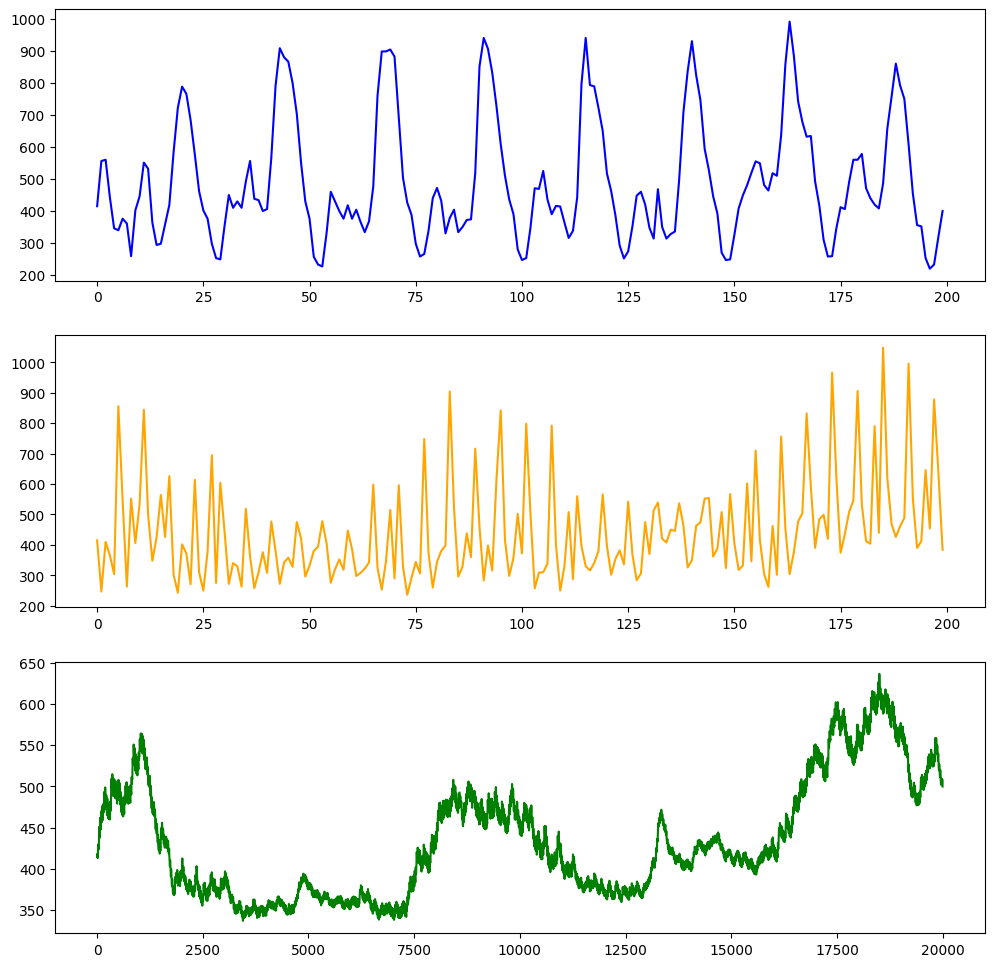

In [10]:
# ================================================================== #
#         START OF YOUR CODE (DO NOT DELETE/MODIFY THIS LINE)        #
# ================================================================== #

eu = np.array(df_train["electricity_usage"])

window_plot = eu[:200]
subsample_plot = eu[0::100]

smoothed_plot = []
for i, val in enumerate(eu):
    if i == 0:
        smoothed_plot.append(val)
    else:
        smoothed_plot.append(val * (1 - 0.99) + smoothed_plot[-1] * 0.99)
smoothed_plot = np.array(smoothed_plot)    

# print(eu.shape, window_plot.shape, subsample_plot.shape, smoothed_plot.shape)

fig, axes = plt.subplots(3, 1, figsize=(12, 12))
axes[0].plot(window_plot, color="blue")
axes[1].plot(subsample_plot, color="orange")
axes[2].plot(smoothed_plot, color="green")
plt.show()

# ================================================================== #
#          END OF YOUR CODE (DO NOT DELETE/MODIFY THIS LINE)         #
# ================================================================== #

### [답안 검증 1-2]

조건을 맞추어 구현했을 시 아래와 같은 그림과 비슷한 plot을 얻게 되고, 아래 코드에서 오류가 없다.

![sample fig](./figs/sample_fig_1_2.png)

In [11]:
assert window_plot.shape == (200,)
assert subsample_plot.shape == (200,)
assert smoothed_plot.shape == (20000,)

### [답안 제출 1-2] 수정 금지, 실행만 하시오.

In [12]:
skada.Q1_2_answer(fig)

저장 완료. 최종 제출을 위해선 런박스 상단의 제출버튼을 눌러주세요.


## [문제 1-3]
### [이론 설명 1-3]
앞서 확인한 것 처럼 테스트 데이터는 부분이 결손되어있다. 결손된 부분을 채우는 모델을 학습시키기 위해서는 결손된 부분의 특징을 분석하는 것이 필요하다. 주기적으로 결손된 데이터를 찾는데에는 AutoCorrelation Function (ACF)를 이용할 수 있다. 이 때, ACF는 다음 과 같이 정의된다.

$$
R[k] = \sum_{t} (x_t - \mu)(x_{t+k} - \mu)
$$

여기서, $\mu := \frac{1}{N}\sum_{t} x_t$ 는 전체 시계열의 평균값이며, $k$ 는 ACF의 인덱스, $t$는 기존 시계열의 시간 인덱스, $N$은 전체 시계열의 길이를 뜻한다.

일반적으로 ACF를 계산할 때 분산으로 값을 나눠주는 정규화 과정을 거친다.

$$
\sigma^2 = \frac{1}{N} \sum_{t=1}^N (x_t - \mu)^2
$$

라고 정의 할 때, 정규화된 ACF는 아래와 같이 표현된다.

$$
\hat{R}[k] = R[k] / \sigma^2.
$$

### [문제 설명 1-3] ACF를 통한 테스트 데이터 분석 (6점)
아래 조건에 따라 ACF를 계산하는 함수를 [```np.correlate```](https://numpy.org/doc/2.1/reference/generated/numpy.correlate.html) 함수를 이용해 구현해보자.

**Hint**: ```np.correlate(x, x, mode='full')``` 은 다음을 계산한다:
$$
C(k) = \sum_t x_t x_{t-k}, \quad k \in [-N+1, N-1]
$$


- 조건 1: ```max_lag``` 인자를 받아 $R[k]$의 총 길이를 truncation하여 조절할 수 있는 함수를 구현한다. 예를 들어, ```max_lag```가 ```M```이라면, $k=0$부터 $k=M-1$까지만 리턴한다.
- 조건 2: 리턴되는 데이터타입은 ```np.ndarray```이다.
- 조건 3: 구현된 ```ACF```함수를 이용하여 테스트 데이터의 ACF를 계산하고 이를 ```acf_values```에 저장한다. 이 때, ```max_lag=500```으로 설정한다.
- 조건 4: normalize를 진행하여 $\hat{R}[k]$를 구현하게 한다.
- 조건 5: ACF 함수는 $k \geq 1$ 에서 정의되는 함수이므로, ```acf_values```의 첫 인덱스를 제외한 최댓값을 갖는 인덱스를 계산한다. 이를 ```max_index```에 저장한다.

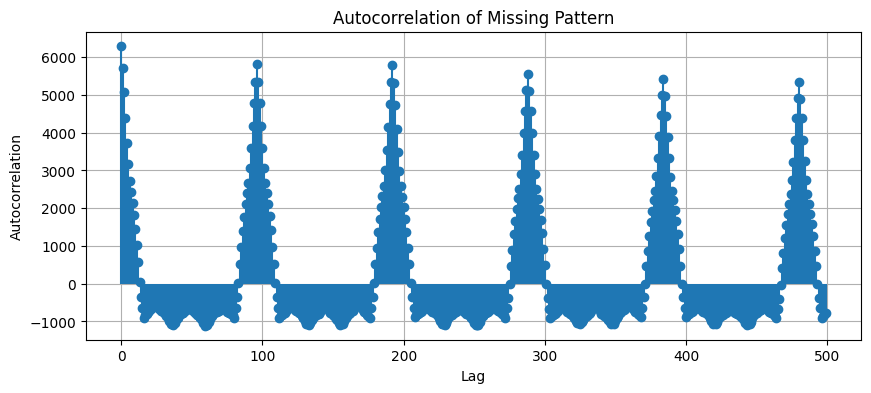

In [13]:
# 만약 1-1을 제대로 풀지 못했다면, 다음 코드로 df_test를 정상화한다.
df_test['electricity_usage'] = df_test['electricity_usage'].fillna(0)

# ================================================================== #
#         START OF YOUR CODE (DO NOT DELETE/MODIFY THIS LINE)        #
# ================================================================== #

def CustomACF(x, max_lag=500):
    
    x = x - x.mean()
    std = np.std(x)
    N = len(x)
    
    cov = np.correlate(x, x, mode="full")
    cov_trunc = cov[N-1:N-1 + max_lag]
    
    corr = cov_trunc / std ** 2
    
    return corr

acf_values = CustomACF(df_test["electricity_usage"], max_lag=500)

max_index = np.argmax(acf_values[1:]) + 1


# ================================================================== #
#          END OF YOUR CODE (DO NOT DELETE/MODIFY THIS LINE)         #
# ================================================================== #

# 시각화
lags = np.arange(500)
plt_obj = plt.figure(figsize=(10, 4))
plt.stem(lags, acf_values, basefmt=" ")
plt.xlabel("Lag")
plt.ylabel("Autocorrelation")
plt.title("Autocorrelation of Missing Pattern")
plt.grid()
# plt_obj에 저장된 Figure를 활용해 나중에 저장 가능
# plt_obj.savefig("acf_plot.png")

# 플롯 표시
plt.show()

In [14]:
max_index

np.int64(96)

### [답안 검증 1-3]

`ACF` 함수가 정상적으로 구현이 되었다면 아래와 같은 ACF plot을 얻을 수 있고, 셀을 실행시켰을 때 오류가 발생하지 않는다.

![acf](./figs/sample_fig_1_3.png)

In [15]:
assert acf_values.shape == (500, )

### [답안 제출 1-3] 수정 금지, 실행만 하시오.


In [16]:
skada.Q1_3_answer((acf_values, int(max_index)))

저장 완료. 최종 제출을 위해선 런박스 상단의 제출버튼을 눌러주세요.


# Ⅱ. Imputation 모델 구현
## [문제 2-1]

### [상황 설명 2-1]
학습 데이터에는 결손된 부분이 없고, 테스트 데이터에는 결손된 부분이 있다. 우리는 사전에 분석한 테스트 데이터의 결손된 부분의 특징을 활용하여 학습 데이터를 사후적(retrospective)으로 마스킹(masking) 하여 결손된 부분을 예측하는 모델을 학습한다.


### [문제 설명 2-1] 윈도우화시키는 Pytorch Dataset 구현 (4점)

아래 조건에 따라 ```ElectricityDataset```의 ```__init__``` constructor를 구현해보자.

- 조건 1: 주어진 ```window_size```에 맞게 윈도우화를 하여 모든 샘플을 ```self.samples```에 리스트 형태로 저장한다.
- 조건 2: ```self.samples``` 리스트에 저장되는 값들은 ```electricity_usage``` 플로팅포인트 값들을 pytorch tensor 타입으로 변환한 텐서들이다. 이 텐서들의 shape은 ```(window_size, 1)```이다.
- 조건 3: ```normalize=True```라면, 전체 데이터의 평균 ($\mu$) 과 표준편차 ($\sigma$) 값에 따라 정규화를 해준다. 표준화된 신호의 식은 $\bar{x}_t = (x_t - \mu) / \sigma$ 로 표현된다. 이 때, $\mu$ 와 $\sigma$ 는 각각 ```self.mean```, ```self.std```에 저장한다.
- 조건 4: 기존 ```df_test```의 NaN 값이었던 부분이 0으로 채워져있지만 이 부분은 값을 0으로 유지해야하므로, ```mask```를 인자로 받아 해당 부분만큼은 값을 0으로 유지한다.
- 조건 5: ```overlap=True```라면, stride = 1로 윈도우를 겹치게 샘플링한다. 이 때, 윈도우가 전체 길이를 넘어가는 경우는 ```self.samples```에 포함시키지 않는다. 예를 들어, ```x```의 길이가 100이고, ```window_size=16```이라면, ```self.samples```에 포함되는 것이 가능한 마지막 윈도우는 ```x[84:]```가 되어야 한다.
- 조건 6: ```overlap=False```라면 ```stride```와 ```window_size```가 동일하다.

In [36]:
class ElectricityDataset(Dataset):
    def __init__(self, df, 
                 window_size=96,
                 normalize=True,
                 overlap=True,
                 mask=None):
        """
        Args:
            df (pd.dataframe): pandas dataframe
            window_size (int): 윈도우의 길이.
            normalize (bool): 정규화 진행 여부.
            overlap (bool): 겹치는 윈도우를 사용할지에 대한 여부.
            mask (np.ndarray): 해당 부분이 비어있었는지에 대한 여부를 나타내는 bool 타입의 ndarray.
        """
        # ================================================================== #
        #         START OF YOUR CODE (DO NOT DELETE/MODIFY THIS LINE)        #
        # ================================================================== #
        
        self.df = df
        self.window_size = window_size
        
        self.stride = 1 if overlap else window_size
        
        self.data = np.array(df["electricity_usage"])
        self.data = torch.tensor(self.data, dtype=float)
        
        if normalize:
            self.mean, self.std = self.data.mean(), self.data.std()
            
            self.data = (self.data - self.mean) / self.std
            
            if mask is not None:
#                 print(mask.shape, self.data.shape)
                self.data = self.data[:, None]
                self.data = self.data * (1 - mask) + torch.zeros_like(self.data) * mask
                self.data = self.data[:, 0].float()
#                 print(self.data, self.data.shape)
        
        self.samples = []
        
        for i in range(0, len(self.data) - window_size + 1, self.stride):
            self.samples.append(self.data[i:i+window_size, None].float())
            
        # ================================================================== #
        #          END OF YOUR CODE (DO NOT DELETE/MODIFY THIS LINE)         #
        # ================================================================== #

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        return self.samples[idx]  # Returns a (window_size, num_features) tensor

### [답안 검증 2-1]
`ElectricityDataset` 클래스가 정상적으로 구현이 되었다면 아래 셀을 실행시켰을 때 오류가 발생하지 않는다.

In [37]:
# 데이터셋, 데이터로더 정의
total_length = len(df_train)
cutoff = int(total_length * 0.8)

train_dataset = ElectricityDataset(df_train.iloc[:cutoff, ...], window_size=96, overlap=True)
val_dataset = ElectricityDataset(df_train.iloc[cutoff:, ...], window_size=96, overlap=True)
test_dataset = ElectricityDataset(df_test, window_size=96, overlap=False, mask=mask)

train_dataloader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_dataloader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_dataloader = DataLoader(test_dataset, batch_size=1, shuffle=False)

assert len(train_dataset) == 15905
assert len(val_dataset) == 3905
assert len(test_dataset) == 65

### [답안 제출 2-1]  수정 금지, 실행만 하시오.

In [38]:
skada.Q2_1_answer((train_dataset, val_dataset, test_dataset))

저장 완료. 최종 제출을 위해선 런박스 상단의 제출버튼을 눌러주세요.


## [문제 2-2]

### [이론 및 상황 설명 2-2]
지금까지 처리된 데이터셋을 이용해 결손 예측을 수행할 수 있는 네트워크를 학습시킬 수 있다. 결손 예측을 잘 수행하기 위해선 수용 범위(receptive field)가 충분히 큰 모델이 유리하므로, 1D strided convolution 기반의 U-Net 구조를 가지는 네트워크를 우선 구현해보자.

![U-Net Figure](./figs/UNet.png)

U-Net은 입력과 출력의 크기를 동일하게 가져갈 수 있으며, 풀링(pooling)을 통해 수용 범위를 크게 가져갈 수 있는 모델이다. 나아가, feature의 풀링 레벨별로 skip connection을 달아 효율적인 네트워크 학습이 가능하다.

### [문제 설명 2-2] 1D U-Net 모델 구조 구현 (6점)

위의 그림과 아래 조건에 따라 ```Decoder``` 클래스의 ```forward```함수와, ```UNet1D``` 클래스의 ```forward``` 함수를 구현해보자.

- 조건 1: ```Decoder``` 클래스의 ```forward```함수는 ```Encoder``` 클래스의 ```forward```와 대칭적인 구조를 갖는다. ```x3```는 ```self.deconv1``` 와 ReLU 활성 함수를 통과해 ```z2```를 만들고, 이는 ```x2```와 더해지는 skip connection 구조를 취한다.
- 조건 2: ```z2```가 ```self.deconv2```와 ReLU 활성 함수를 통과하여 ```x1```과 더해져 ```z1```을 만들고, 이는 마지막으로 ```self.deconv3```을 통과하여 최종 출력인 ```z```를 만든다.
- 조건 3: ```UNet1D``` 클래스의 ```forward```는 우선 ```[B, L, C]```의 입력을 받아들여, 이를 ```[B, C, L]``` 순서로 재배열(permute)하는 과정을 거친다. 이는 ```self.encoder```, ```self.decoder```를 순차적으로 통과하여 ```[B, C, L]```모양의 텐서를 만들고, 이를 다시 재배열하여 최종 output을 만든다.
- 조건 4: ```UNet1D``` 모델은 residual 구조를 가진다. 다시 말해, ```forward```의 인자인 ```x```를 최종 출력에 더하여 리턴한다.


In [39]:
class Encoder(nn.Module):
    def __init__(self, input_dim, hidden_dim, latent_dim):
        super().__init__()
        self.conv1 = nn.Conv1d(input_dim,    hidden_dim, kernel_size=4, stride=2, padding=1)
        self.conv2 = nn.Conv1d(hidden_dim,   hidden_dim, kernel_size=4, stride=2, padding=1)
        self.conv3 = nn.Conv1d(hidden_dim,   latent_dim, kernel_size=4, stride=2, padding=1)

    def forward(self, x):
        # x 모양: [batch, channels, seq_len]
        x1 = F.relu(self.conv1(x))  # e.g. seq_len: 96 -> 48
        x2 = F.relu(self.conv2(x1)) # e.g. 48 -> 24
        x3 = self.conv3(x2)         # e.g. 24 -> 12 (마지막은 raw latent이므로 활성화 없음)
        return x1, x2, x3

class Decoder(nn.Module):
    def __init__(self, latent_dim, hidden_dim, output_dim):
        super().__init__()
        self.deconv1 = nn.ConvTranspose1d(latent_dim,   hidden_dim, kernel_size=4, stride=2, padding=1)
        self.deconv2 = nn.ConvTranspose1d(hidden_dim,   hidden_dim, kernel_size=4, stride=2, padding=1)
        self.deconv3 = nn.ConvTranspose1d(hidden_dim,   output_dim, kernel_size=4, stride=2, padding=1)

    def forward(self, x1, x2, x3):
        # ================================================================== #
        #         START OF YOUR CODE (DO NOT DELETE/MODIFY THIS LINE)        #
        # ================================================================== #
        # x1 shape: (batch, latent_dim*2, seq_len//2)
        # x2 shape: (batch, latent_dim*2, seq_len//4)
        # x3 shape: (batch, latent_dim, seq_len//8),
        
        z2 = F.relu(self.deconv1(x3)) + x2
        z1 = F.relu(self.deconv2(z2)) + x1
        z = self.deconv3(z1)
        
        # ================================================================== #
        #         END   OF YOUR CODE (DO NOT DELETE/MODIFY THIS LINE)        #
        # ================================================================== #
        return z

class UNet1D(nn.Module):
    def __init__(self, input_dim, hidden_dim, latent_dim):
        super().__init__()
        self.encoder = Encoder(input_dim, hidden_dim, latent_dim)
        self.decoder = Decoder(latent_dim, hidden_dim, input_dim)

    def forward(self, x):
        # ================================================================== #
        #         START OF YOUR CODE (DO NOT DELETE/MODIFY THIS LINE)        #
        # ================================================================== #
        # (batch, seq_len, channels) -> (batch, channels, seq_len)
        # encoder
        # decoder output shape: (batch, channels, seq_len)
        # residual connection
        # (batch, channels, seq_len) -> (batch, seq_len, channels)
        
        x = x.permute(0, 2, 1)
        x1, x2, x3 = self.encoder(x)
        z = self.decoder(x1, x2, x3)
        x_recon = z + x
        x_recon = x_recon.permute(0, 2, 1)
        
        
        # ================================================================== #
        #         END   OF YOUR CODE (DO NOT DELETE/MODIFY THIS LINE)        #
        # ================================================================== #
        return x_recon


### [답안 검증 2-2]

2-1과 2-2 문제를 모두 풀었다면 아래 셀을 실행 시켰을 때 문제가 없다.

In [40]:
device = 'cuda:0'
batch = next(iter(train_dataloader))
batch = batch.to(device)
model = UNet1D(input_dim=1, hidden_dim=128, latent_dim=64).to(device)

output = model(batch)

assert batch.shape == (32, 96, 1)
assert output.shape == (32, 96, 1)

### [답안 제출 2-2]  수정 금지, 실행만 하시오.

In [41]:
skada.Q2_2_answer((Decoder.forward, UNet1D.forward))

저장 완료. 최종 제출을 위해선 런박스 상단의 제출버튼을 눌러주세요.


# III. 모델 학습 및 검증
## [문제 3-1]

### [상황 설명 3-1]
지금까지 준비된 모델과 데이터셋을 통해 모델을 학습한다. 이전의 문제를 제대로 풀지 못했다면, 아래 코드에 주어진 모델을 이용해서 나머지 문제를 푸는 것이 가능하다.

문제 1-3에서 확인한 ACF 그래프를 보면 결손데이터가 96만큼의 주기로 존재할 것을 추정할 수 있다. 이 것이 실제로 맞는지 확인하기 위해, ```window_size=96```으로 잡고 테스트 데이터로더에서 나온 타임시리즈의 특징을 확인해 볼 수 있다.

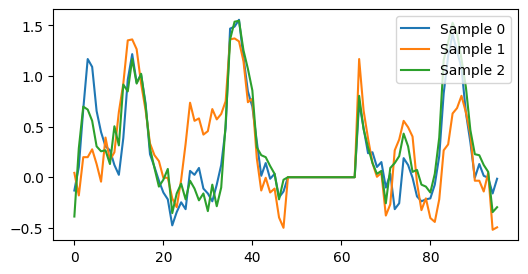

In [42]:
test_dataset = ElectricityDataset(df_test, window_size=96, overlap=False, mask=mask)
test_dataloader = DataLoader(test_dataset, batch_size=1, shuffle=False)

plt.figure(figsize=(6, 3))
cnt = 0

for batch in test_dataloader:
    plt.plot(batch.squeeze().cpu().numpy(), label=f"Sample {cnt}")  # 각 샘플을 같은 그래프에 플로팅
    cnt += 1
    if cnt > 2:
        break

plt.legend()  # 범례 추가
plt.show()

In [43]:
mask_flat = mask.squeeze()  

# 주기 설정
window_size = 96
missing_start = 48
missing_length = 16

# 검증
num_windows = len(mask_flat) // window_size
valid = True

for i in range(num_windows):
    start_idx = i * window_size + missing_start
    end_idx = start_idx + missing_length       
    
    if not np.all(mask_flat[start_idx:end_idx]):
        print(f"❌ 패턴 불일치 at window {i}: {mask_flat[start_idx:end_idx]}")
        valid = False

if valid:
    print("✅ 모든 윈도우에서 48번 인덱스부터 16개가 결손치(True)")


✅ 모든 윈도우에서 48번 인덱스부터 16개가 결손치(True)


위 그림과 코드에서, 결손된 부분은 96의 주기를 가지고 같은 위치에서 발생하며, 시작지점은 48번째 인덱스, 그리고 그 길이가 16임을 확인할 수 있다.

In [44]:
# class SimpleEncoder(nn.Module):
#     def __init__(self, input_dim, hidden_dim, latent_dim):
#         super().__init__()
#         self.conv1 = nn.Conv1d(input_dim, hidden_dim, kernel_size=4, stride=2, padding=1)
#         self.conv2 = nn.Conv1d(hidden_dim, hidden_dim, kernel_size=4, stride=2, padding=1)
#         self.conv3 = nn.Conv1d(hidden_dim, latent_dim, kernel_size=4, stride=2, padding=1)

#     def forward(self, x):
#         x = F.relu(self.conv1(x))  # seq_len: 96 -> 48
#         x = F.relu(self.conv2(x))  # 48 -> 24
#         x = self.conv3(x)          # 24 -> 12 (마지막 피쳐에는 활성화 함수 없음)
#         return x

# class SimpleDecoder(nn.Module):
#     def __init__(self, latent_dim, hidden_dim, output_dim):
#         super().__init__()
#         self.deconv1 = nn.ConvTranspose1d(latent_dim, hidden_dim, kernel_size=4, stride=2, padding=1)
#         self.deconv2 = nn.ConvTranspose1d(hidden_dim, hidden_dim, kernel_size=4, stride=2, padding=1)
#         self.deconv3 = nn.ConvTranspose1d(hidden_dim, output_dim, kernel_size=4, stride=2, padding=1)

#     def forward(self, x):
#         x = F.relu(self.deconv1(x))  # 12 -> 24
#         x = F.relu(self.deconv2(x))  # 24 -> 48
#         x = self.deconv3(x)          # 48 -> 96
#         return x

# class Autoencoder1D(nn.Module):
#     def __init__(self, input_dim, hidden_dim, latent_dim):
#         super().__init__()
#         self.encoder = SimpleEncoder(input_dim, hidden_dim, latent_dim)
#         self.decoder = SimpleDecoder(latent_dim, hidden_dim, input_dim)

#     def forward(self, x):
#         x = x.permute(0, 2, 1)  # (B, L, C) -> (B, C, L)
#         x_latent = self.encoder(x)
#         x_recon = self.decoder(x_latent)
#         x_recon = x_recon.permute(0, 2, 1)  # (B, C, L) -> (B, L, C)
#         return x_recon

# model = Autoencoder1D(input_dim=1, hidden_dim=128, latent_dim=64).to(device)

이제 주어진 모델을 ```train_imputation```함수로 학습시킨다.

결손 예측을 학습하기 위해서는 데이터가 결손되어있는 입력이 모델에 들어가야하는데, dataloader로부터 나오는 ```batch```는 결손된 데이터가 아니다. 이를 학습하기 위해서는 테스트 데이터와 동일하게 연속된 값이 결손되도록 가운데 부분을 마스킹할 수 있다.

### [문제 설명 3-1] 모델 학습 구현 (6점)
아래 조건에 따라 ```train_imputation```함수를 완성해보자. 

- 조건 1: 길이가 ```window_size```인 ```batch```가 주어졌을 때, 동일하게 48번째 인덱스부터 길이가 16인 부분만큼을 마스킹하여 이를 ```masked_batch```에 저장한다. 이 때 마스킹된부분의 값은 0으로 채운다.
- 조건 2: ```masked_batch```는 ```model```의 입력으로 들어가며 ```x_recon```을 만든다.
- 조건 3: ```x_recon```은 정답 값인 ```batch```의 값과 비교하여 mse loss를 구하고, 이는 ```loss```에 저장된다.
- 조건 4: 정확히 동일한 파이프라인을 training과 validation파트에 구현한다.

### [답안 검증 3-1]

제대로 구현을 했다면, 중간에 있는 assert 문에서 오류가 발생하지 않는다.

In [45]:
def train_imputation(model, train_dataloader, val_dataloader, epochs=10, lr=1e-3, device='cuda'):
    model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()

    seq_length = 96  # 시계열 (윈도우)의 길이
    mask_length = 16  # 연속적으로 마스크되는 영역의 길이
    start = 48

    for epoch in range(epochs):
        train_loss = 0.0
        model.train()
        """
        Training steps
        """
        for batch in train_dataloader:
            optimizer.zero_grad()
            batch = batch.to(device)  # Shape: [batch_size, 96, 1]

            # ================================================================== #
            #         START OF YOUR CODE (DO NOT DELETE/MODIFY THIS LINE)        #
            # ================================================================== #
            
            masked_batch = batch.clone()
            masked_batch[:, start:start+mask_length] = 0
            
            x_recon = model(masked_batch)
            
            loss = criterion(x_recon, batch)

            # ================================================================== #
            #         END   OF YOUR CODE (DO NOT DELETE/MODIFY THIS LINE)        #
            # ================================================================== #
            num_zeros = (masked_batch == 0).sum().item()
            expected_zeros = mask_length * batch.shape[0]
            assert num_zeros == expected_zeros
            assert x_recon.shape == batch.shape

            loss.backward()
            optimizer.step()

            train_loss += loss.item()
        """
        Validation steps
        """
        val_loss = 0.0
        model.eval()
        with torch.no_grad():
            for batch in val_dataloader:
                batch = batch.to(device)
                # ================================================================== #
                #         START OF YOUR CODE (DO NOT DELETE/MODIFY THIS LINE)        #
                # ================================================================== #
                
                masked_batch = batch.clone()
                masked_batch[:, start:start+mask_length] = 0

                x_recon = model(masked_batch)

                loss = criterion(x_recon, batch)

                # ================================================================== #
                #         END   OF YOUR CODE (DO NOT DELETE/MODIFY THIS LINE)        #
                # ================================================================== #
                num_zeros = (masked_batch == 0).sum().item()
                expected_zeros = mask_length * batch.shape[0]
                assert num_zeros == expected_zeros
                assert x_recon.shape == batch.shape

                val_loss += loss.item()

        avg_train_loss = train_loss / len(train_dataloader)
        avg_val_loss = val_loss / len(val_dataloader)
        if epoch % 5 == 0:
            print(f"Epoch {epoch+1}/{epochs}, Train loss: {avg_train_loss:.4f}, Val_loss: {avg_val_loss:.4f}")
    print("Training completed.")


# Train the model
model = UNet1D(input_dim=1, hidden_dim=128, latent_dim=64).to(device)
train_imputation(model, train_dataloader, val_dataloader, epochs=50, lr=1e-3, device='cuda')

Epoch 1/50, Train loss: 0.1381, Val_loss: 0.0902
Epoch 6/50, Train loss: 0.0407, Val_loss: 0.0722
Epoch 11/50, Train loss: 0.0345, Val_loss: 0.0630
Epoch 16/50, Train loss: 0.0292, Val_loss: 0.0625
Epoch 21/50, Train loss: 0.0261, Val_loss: 0.0566
Epoch 26/50, Train loss: 0.0234, Val_loss: 0.0633
Epoch 31/50, Train loss: 0.0211, Val_loss: 0.0635
Epoch 36/50, Train loss: 0.0203, Val_loss: 0.0599
Epoch 41/50, Train loss: 0.0178, Val_loss: 0.0604
Epoch 46/50, Train loss: 0.0164, Val_loss: 0.0582
Training completed.


### [답안 제출 3-1]  수정 금지, 실행만 하시오.

In [46]:
skada.Q3_1_answer(train_imputation)

저장 완료. 최종 제출을 위해선 런박스 상단의 제출버튼을 눌러주세요.


## [문제 3-2]

### [상황 설명 3-2]
지금까지 준비된 모델과 데이터셋을 통해 모델을 학습했다. 이전의 문제를 제대로 풀지 못했다면, 아래 코드를 통해 미리 학습된 모델의 웨이트를 로딩해와서 다음 문제를 풀 수 있다.

In [47]:
def load_model(model, path="./models/imputation_weight.pt", device='cuda'):
    if not os.path.exists(path):
        raise FileNotFoundError(f"No model weights found at {path}")

    model.load_state_dict(torch.load(path, map_location=device))
    print(f"Model weights loaded from {path}")
    return model

# UNet1D 모델 문제를 해결한 경우
path = "./models/imputation_weight.pt"

# UNet1D 모델 문제를 해결하지 못한 경우
# path = "./models/imputation_simple_weight.pt"

model = load_model(model, path=path)

Model weights loaded from ./models/imputation_weight.pt


학습된 모델과 ```visualize_reconstruction```함수를 통해 테스트셋에 대한 결손 예측 성능을 확인해볼 수 있다. 

### [문제 설명 3-2] 모델 추론 및 시각화 (4점)
```visualize_reconstruction```함수를 아래 조건에 따라 구현해보자.

(```start```와 ```mask_length```는 문제 3-1과 동일한 값을 사용하자.)

- 조건 1: test dataloader로부터 순차적으로 나오는 3개의 윈도우 데이터에 대해 ```[start:start+mask_length]``` 만큼 마스크를 씌우고, 이를 ```model```을 통과시켜 결손 예측을 수행한다.
- 조건 2: 순차적으로 나오는 윈도우는 연속적이기에, 이 연속적인 값들을 하나의 시계열로 만들어야한다. 마스킹된 입력은 ```original_series``` 하나로 연결(concatenate)하고, 결손 예측이 완료된 출력은 ```reconstructed_series``` 하나로 연결하여 만든다.
- 조건 3: ```test_dataset``` 클래스는 ```normalize=True```로 설정되어있기 때문에 입력과 출력값이 정규화되어있는 상태이다. 이를 원래의 레인지(range)로 돌려놓기 위해 ```test_dataset```의 attritube을 활용하여 역정규화(unnormalization)를 진행하여, 각각을 ```un_original_series```, ```un_reconstructed_series```에 저장한다.

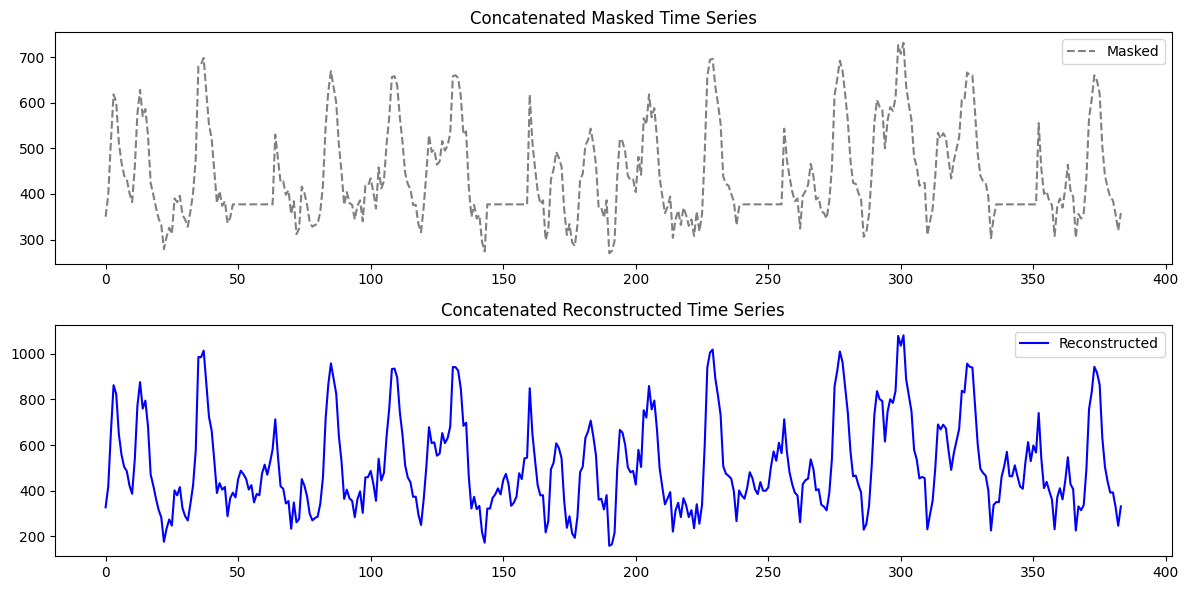

In [50]:
def visualize_reconstruction(model, dataloader, device='cuda'):
    model.eval()
    
    # ================================================================== #
    #         START OF YOUR CODE (DO NOT DELETE/MODIFY THIS LINE)        #
    # ================================================================== #
    
    original_series = []
    reconstructed_series = []
    
    for i, batch in enumerate(dataloader):
        if i > 3:
            break
        
        masked_batch = batch.clone()
        start, mask_length = 48, 16
        masked_batch[:, start:start+mask_length] = 0
        
        with torch.no_grad():
            masked_batch = masked_batch.to(device)
            x_recon = model(masked_batch)
        
        original_series.append(masked_batch.cpu().numpy())
        reconstructed_series.append(x_recon.cpu().numpy())
        
    original_series = np.concatenate(original_series, axis=1)
    reconstructed_series = np.concatenate(reconstructed_series, axis=1)
    
    un_original_series = original_series * test_dataset.std.cpu().numpy() + test_dataset.mean.cpu().numpy()
    un_reconstructed_series = reconstructed_series * test_dataset.std.cpu().numpy() + test_dataset.mean.cpu().numpy()
    
    # ================================================================== #
    #         END OF YOUR CODE (DO NOT DELETE/MODIFY THIS LINE)          #
    # ================================================================== #

    # 시각화
    fig, axes = plt.subplots(2, 1, figsize=(12, 6))

    axes[0].plot(un_original_series[0, :, 0], label='Masked', color='gray', linestyle='dashed')
    axes[0].set_title('Concatenated Masked Time Series')
    axes[0].legend()

    axes[1].plot(un_reconstructed_series[0, :, 0], label='Reconstructed', color='blue')
    axes[1].set_title('Concatenated Reconstructed Time Series')
    axes[1].legend()

    plt.tight_layout()

    return fig


fig = visualize_reconstruction(model, test_dataloader, device='cuda')

### [답안 검증 3-2]

제대로 구현을 했다면, 아래와 비슷한 plot을 얻을 수 있다.

![sample_plot_3_2](./figs/sample_fig_3_1.png)

### [답안 제출 3-2]   수정 금지, 실행만 하시오.



In [51]:
skada.Q3_2_answer((visualize_reconstruction, fig))

저장 완료. 최종 제출을 위해선 런박스 상단의 제출버튼을 눌러주세요.


이 프로젝트를 통해, **센서 오작동으로 발생한 결측 데이터를 머신러닝을 활용해 복원하는 과정**을 다루었다.
우선 데이터를 전처리하고, **신호처리 기법을 통해 결측 구간의 특성을 분석**하였다.
이후 **UNet 모델을 활용하여 결측 영역을 복원할 수 있는 모델을 학습**하고,
최종적으로 **복원 결과를 시각화하여 모델의 성능을 직관적으로 확인**할 수 있었다.

# 주관식 문제 종료
## 반드시 오른쪽 상단의 제출 버튼을 눌러 답안을 최종 제출하시오.